In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()

while not (PROJECT_ROOT / "src").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("找不到项目根目录（包含 src 的目录）")
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /home/joyce/projects/cross-asset-quant-lab/cryptoAlpha


In [12]:
import pandas as pd
import numpy as np

from src.factors.factor_builder import FactorBuilder
from src.models.xgb_alpha_model import XGBAlphaModel
from src.evaluation.multi_horizon_plotter import MultiHorizonPlotter

## 低频数据处理与因子构建流程

这个项目的低频研究流程可以分成两层。第一层是 **panel 构建**，目标是把 Coinglass、CoinGecko、Cryptoracle 的多源 1 小时数据统一到同一个 `datetime`–`symbol` 面板上。第二层是 **factor 构建**，目标是在这个统一面板上按币种时间序列计算动量、资金费率、持仓量、主动买卖量、社交活跃度等因子。

在数据处理阶段，`DataRegistry` 先读取路径配置，然后各个 loader 分别从不同源加载原始 csv。每个数据源都会先做标准化：统一时间列为 `datetime`，统一资产列为 `symbol`，并把原始字段重命名成项目内部使用的标准字段名，例如 `funding_close`、`oi_close`、`taker_buy_volume_usd`、`market_cap`、`active_community_count` 等。之后 `build_base_panel()` 会以 `datetime` 和 `symbol` 为键做外连接合并，得到基础 panel。再通过 `filter_panel_by_time()` 裁剪时间区间，并缓存为 parquet。

在因子构建阶段，`FactorBuilder` 读取 panel 中的标准字段，按币种分组后调用 `factor_utils` 里的滚动函数完成计算。例如动量因子使用 `pct_change_by_symbol()`，资金费率和多空比使用 `rolling_zscore_by_symbol()`，成交量相关因子使用 `rolling_mean_by_symbol()` 或 `rolling_std_by_symbol()`。每个单因子计算结果都只保留 `datetime`、`symbol` 和该因子本身，然后 `compute_many()` 再把所有单因子结果按键合并成总的 `factor_df`。

In [ ]:
from src.data.registry import DataRegistry
from src.data.panel_builder import build_base_panel, filter_panel_by_time
from src.data.loaders.coinglass_loader import CoinglassLoader
from src.data.loaders.coingecko_loader import CoingeckoLoader
from src.data.loaders.cryptoracle_loader import CryptoracleLoader
from src.factors.factor_builder import FactorBuilder

START_TIME = "2025-01-01"
END_TIME = "2026-03-11"

SYMBOLS = [
    "BTCUSDT", "ETHUSDT", "BNBUSDT", "XRPUSDT", "SOLUSDT",
    "DOGEUSDT", "ADAUSDT", "TRXUSDT", "LINKUSDT", "LTCUSDT",
    "AVAXUSDT", "MATICUSDT", "DOTUSDT", "BCHUSDT", "XLMUSDT",
    "ATOMUSDT", "NEARUSDT", "ETCUSDT", "FILUSDT", "APTUSDT",
]

CRYPTORACLE_METRICS = [
    "active_community_count",
    "mention_count",
    "positive_sentiment_ratio",
    "negative_sentiment_ratio",
]

registry = DataRegistry(str(PROJECT_ROOT / "configs" / "paths.yaml"))

source_table = pd.DataFrame([
    {
        "source": "Coinglass",
        "dataset": "FUTURES_PRICE_HISTORY",
        "standard_columns": "open, high, low, close, volume_usd",
        "main_usage": "价格与成交额基础面板；mom_6h, mom_24h, volume_ratio_24 等",
    },
    {
        "source": "Coinglass",
        "dataset": "FUTURES_FUNDING_RATE_HISTORY",
        "standard_columns": "funding_open, funding_high, funding_low, funding_close",
        "main_usage": "资金费率因子；funding_z_24",
    },
    {
        "source": "Coinglass",
        "dataset": "FUTURES_OPEN_INTEREST",
        "standard_columns": "oi_open, oi_high, oi_low, oi_close",
        "main_usage": "持仓量变化因子；oi_change_24h, oi_volume_ratio",
    },
    {
        "source": "Coinglass",
        "dataset": "FUTURES_TAKER_BUY_SELL_VOLUME",
        "standard_columns": "taker_buy_volume_usd, taker_sell_volume_usd",
        "main_usage": "主动买卖盘不平衡；taker_imbalance",
    },
    {
        "source": "Coinglass",
        "dataset": "FUTURES_GLOBAL_LS_ACCOUNT_RATIO",
        "standard_columns": "global_account_long_percent, global_account_short_percent, global_account_long_short_ratio",
        "main_usage": "多空账户比例；long_short_ratio_z_24",
    },
    {
        "source": "CoinGecko",
        "dataset": "COIN_MARKET_CHART/hourly",
        "standard_columns": "price, market_cap, total_volume",
        "main_usage": "现货价格、市值、现货成交量补充",
    },
    {
        "source": "Cryptoracle",
        "dataset": ", ".join(CRYPTORACLE_METRICS),
        "standard_columns": ", ".join(CRYPTORACLE_METRICS),
        "main_usage": "社交与情绪因子；active_community_count_z_24 等",
    },
])

factor_process_table = pd.DataFrame([
    {"factor": "mom_6h", "depends_on": "close", "method": "按 symbol 分组做 6 小时 pct_change"},
    {"factor": "mom_24h", "depends_on": "close", "method": "按 symbol 分组做 24 小时 pct_change"},
    {"factor": "funding_z_24", "depends_on": "funding_close", "method": "按 symbol 分组做 24 小时 rolling z-score"},
    {"factor": "oi_change_24h", "depends_on": "oi_close", "method": "按 symbol 分组做 24 小时 pct_change"},
    {"factor": "taker_imbalance", "depends_on": "taker_buy_volume_usd, taker_sell_volume_usd", "method": "(buy-sell)/(buy+sell)"},
    {"factor": "long_short_ratio_z_24", "depends_on": "global_account_long_short_ratio", "method": "按 symbol 分组做 24 小时 rolling z-score"},
    {"factor": "volume_ratio_24", "depends_on": "volume_usd", "method": "当前成交额 / 24 小时 rolling mean"},
    {"factor": "active_community_count_z_24", "depends_on": "active_community_count", "method": "按 symbol 分组做 24 小时 rolling z-score"},
])

print("1) 数据源与标准化字段")
display(source_table)

print("2) 因子构建逻辑")
display(factor_process_table)

print("3) 低频 panel 构建的实际顺序")
print("   a. DataRegistry 读取路径配置")
print("   b. 各 loader 从 Coinglass / CoinGecko / Cryptoracle 读取原始 csv")
print("   c. schema.standardize_dataset_df() 统一时间列、symbol 列和字段名")
print("   d. build_base_panel() 按 ['datetime','symbol'] 做 outer merge")
print("   e. filter_panel_by_time() 按时间切片")
print("   f. panel 缓存为 parquet")
print("   g. FactorBuilder.compute_many() 针对每个 factor 按 symbol 做滚动计算")
print("   h. 所有单因子结果再按 ['datetime','symbol'] merge 成 factor_df")

panel_fp = PROJECT_ROOT / "data" / "cache" / "panel_top20_1h_2025_20260311.parquet"
panel_df = pd.read_parquet(panel_fp)

print("\n4) 当前缓存 panel 的字段:")
print(panel_df.columns.tolist())

factor_names = [
    "mom_6h",
    "mom_24h",
    "funding_z_24",
    "oi_change_24h",
    "taker_imbalance",
    "long_short_ratio_z_24",
    "volume_ratio_24",
    "active_community_count_z_24",
]

builder = FactorBuilder()
factor_df = builder.compute_many(panel_df, factor_names)

print("\n5) factor_df 示例:")
display(factor_df.head())

/home/joyce/projects/cross-asset-quant-lab/cryptoAlpha/src/factors/factor_utils.py:32: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  return df.groupby("symbol")[col].pct_change(periods)


factor_df: (197923, 12)


,datetime,symbol,mom_6h,mom_24h,ema_ratio_24,realized_vol_24,volume_ratio_24,funding_z_24,oi_change_24h,taker_imbalance,long_short_ratio_z_24,active_community_count_z_24
14155,2025-02-01 01:00:00,ADAUSDT,0.003806,-0.002626,-0.004919,0.039349,0.636645,0.545626,0.018700,-0.036419,-0.054412,-0.478589
14156,2025-02-01 01:00:00,APTUSDT,-0.016305,-0.000051,-0.015279,0.061188,0.501492,0.436094,0.040329,0.040562,-0.111004,1.174762
14157,2025-02-01 01:00:00,ATOMUSDT,0.002730,0.004344,0.001254,0.039174,0.379577,0.000000,0.021125,-0.059744,0.387127,0.191987
14158,2025-02-01 01:00:00,AVAXUSDT,0.001039,0.004953,0.000517,0.052359,0.473343,0.000000,0.010459,-0.068498,0.546019,0.779174
14159,2025-02-01 01:00:00,BCHUSDT,-0.005198,-0.016951,-0.007371,0.040618,0.590984,0.000000,-0.015713,-0.022784,1.118936,1.181985


In [13]:
builder = FactorBuilder()

builder.list_factors()

['active_community_count_z_24',
 'amihud_illiquidity_24',
 'atr_like_14',
 'close_to_high_24',
 'ema_ratio_24',
 'funding_z_24',
 'long_short_ratio_z_24',
 'ma_gap_24_72',
 'mom_24h',
 'mom_6h',
 'oi_change_24h',
 'oi_volume_ratio',
 'price_range',
 'realized_vol_24',
 'taker_imbalance',
 'trend_strength_12_48',
 'turnover_volatility_24',
 'volatility_ratio_6_24',
 'volume_momentum_6_24',
 'volume_ratio_24']

In [4]:
mh_evaluator = MultiHorizonEvaluator(price_col="close")
mh_plotter = MultiHorizonPlotter()

mh_result = mh_evaluator.evaluate_one_factor_multi_horizon(
    panel_df=panel_df,
    factor_df=factor_df,
    factor_name="taker_imbalance",
    horizons=[1, 3, 6, 12, 24],
    group_num=5,
)

/home/joyce/projects/cross-asset-quant-lab/cryptoAlpha/src/evaluation/factor_evaluator.py:63: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ic = merged_df.groupby("datetime").apply(lambda g: _safe_corr(g["factor"], g[label_col]))
/home/joyce/projects/cross-asset-quant-lab/cryptoAlpha/src/evaluation/factor_evaluator.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rank_ic = merged_df.groupby("datetime").apply(lamb

In [5]:
mh_result["summary_df"]

,factor_name,horizon,n_obs,coverage_mean,ic_mean,ic_std,ic_ir,rank_ic_mean,rank_ic_std,rank_ic_ir,factor_autocorr_mean,top_bottom_mean_ret,top_bottom_std_ret,top_bottom_sharpe_naive,avg_group_turnover
0,taker_imbalance,1,197904,1.0,0.002761,0.253695,0.010883,0.001637,0.249319,0.006567,0.079041,0.000068,0.003511,0.019495,0.858571
1,taker_imbalance,3,197866,1.0,0.003485,0.250473,0.013914,0.002645,0.247549,0.010687,0.079006,0.000166,0.006067,0.027433,0.858586
2,taker_imbalance,6,197809,1.0,0.003150,0.252288,0.012485,0.001782,0.247782,0.007193,0.078942,0.000224,0.008894,0.025176,0.858595
3,taker_imbalance,12,197695,1.0,0.002437,0.252821,0.009641,0.001181,0.247719,0.004766,0.078923,0.000210,0.013028,0.016081,0.858596
4,taker_imbalance,24,197467,1.0,0.005976,0.255494,0.023391,0.003390,0.248358,0.013649,0.078939,0.000406,0.018713,0.021676,0.858608


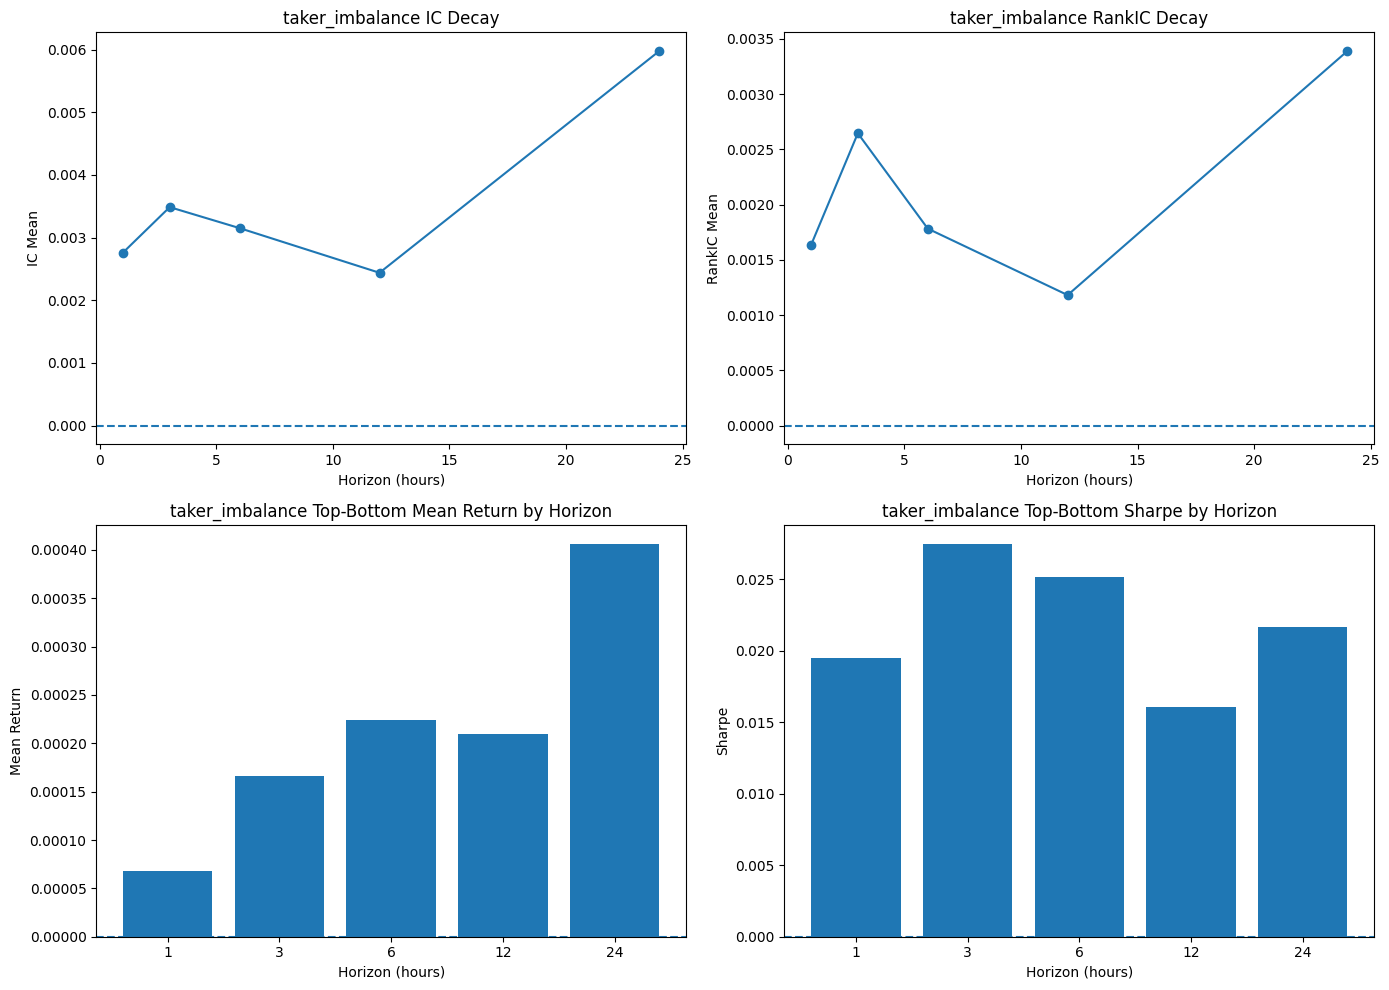

In [6]:
mh_plotter.plot_decay_report(mh_result)

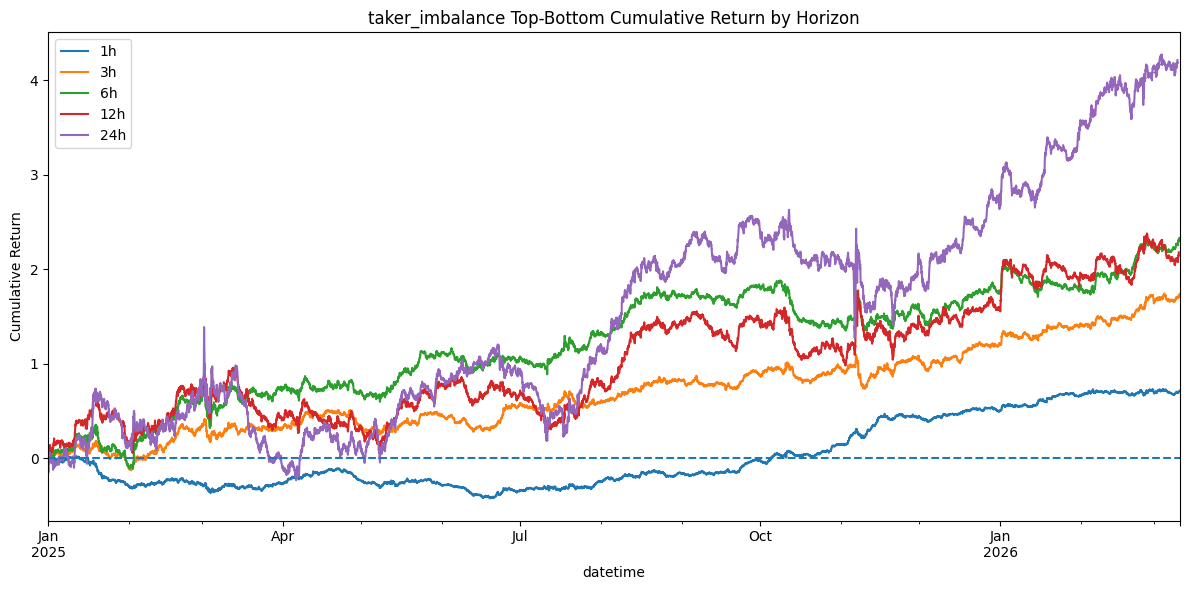

In [7]:
mh_plotter.plot_cumret_by_horizon(mh_result)

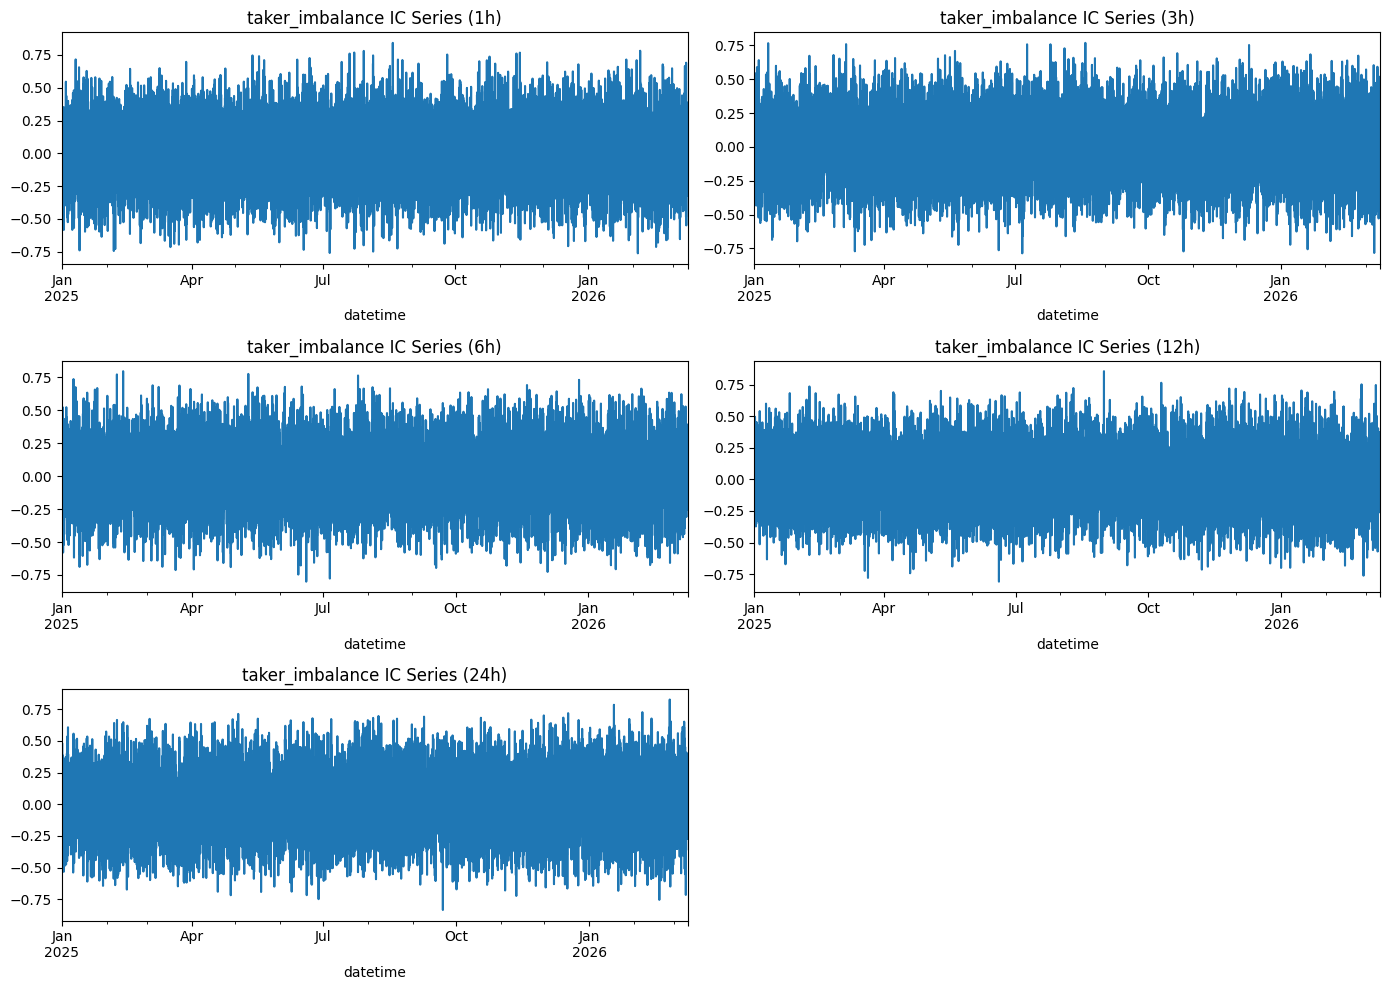

In [8]:
mh_plotter.plot_ic_series_grid(mh_result)

In [9]:
mh_summary_all = mh_evaluator.evaluate_many_factors_multi_horizon(
    panel_df=panel_df,
    factor_df=factor_df,
    factor_names=[
        "long_short_ratio_z_24",
        "volume_ratio_24",
        "funding_z_24",
        "mom_24h",
        "active_community_count_z_24",
    ],
    horizons=[1, 3, 6, 12, 24],
    group_num=5,
)

mh_summary_all

/home/joyce/projects/cross-asset-quant-lab/cryptoAlpha/src/evaluation/factor_evaluator.py:63: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ic = merged_df.groupby("datetime").apply(lambda g: _safe_corr(g["factor"], g[label_col]))
/home/joyce/projects/cross-asset-quant-lab/cryptoAlpha/src/evaluation/factor_evaluator.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rank_ic = merged_df.groupby("datetime").apply(lamb

,factor_name,horizon,n_obs,coverage_mean,ic_mean,ic_std,ic_ir,rank_ic_mean,rank_ic_std,rank_ic_ir,factor_autocorr_mean,top_bottom_mean_ret,top_bottom_std_ret,top_bottom_sharpe_naive,avg_group_turnover
0,active_community_count_z_24,1,164144,1.0,-0.006737,0.267786,-0.025158,-0.005395,0.262918,-0.020520,0.375156,0.000007,0.004034,0.001806,0.799906
1,active_community_count_z_24,3,164144,1.0,-0.008598,0.270439,-0.031794,-0.006808,0.265096,-0.025681,0.375156,-0.000009,0.006750,-0.001358,0.799906
2,active_community_count_z_24,6,164144,1.0,-0.008183,0.266707,-0.030682,-0.007048,0.262325,-0.026868,0.375156,0.000071,0.010275,0.006916,0.799906
3,active_community_count_z_24,12,164144,1.0,-0.004454,0.268058,-0.016614,-0.003485,0.265409,-0.013129,0.375156,0.000322,0.014958,0.021508,0.799906
4,active_community_count_z_24,24,164144,1.0,-0.001601,0.265610,-0.006029,-0.002907,0.263869,-0.011018,0.375156,0.000353,0.021257,0.016587,0.799906
5,funding_z_24,1,197695,1.0,0.007388,0.258686,0.028559,0.005868,0.253690,0.023132,0.887327,0.000086,0.003524,0.024398,0.481187
6,funding_z_24,3,197657,1.0,0.011232,0.257943,0.043544,0.005806,0.254017,0.022856,0.887313,0.000213,0.006278,0.034000,0.481218
7,funding_z_24,6,197600,1.0,0.008083,0.254508,0.031759,0.004087,0.251685,0.016237,0.887292,0.000142,0.008879,0.015972,0.481244
8,funding_z_24,12,197486,1.0,0.000802,0.253564,0.003163,-0.000311,0.251520,-0.001237,0.887268,-0.000128,0.013067,-0.009828,0.481161
9,funding_z_24,24,197258,1.0,-0.000897,0.255556,-0.003512,-0.003414,0.251275,-0.013589,0.887214,-0.000195,0.019428,-0.010025,0.481146


In [10]:
best_horizon_df = (
    mh_summary_all.sort_values(["factor_name", "rank_ic_mean"], ascending=[True, False])
    .groupby("factor_name")
    .head(1)
    .reset_index(drop=True)
)

best_horizon_df[[
    "factor_name",
    "horizon",
    "ic_mean",
    "rank_ic_mean",
    "top_bottom_sharpe_naive",
]]

,factor_name,horizon,ic_mean,rank_ic_mean,top_bottom_sharpe_naive
0,active_community_count_z_24,24,-0.001601,-0.002907,0.016587
1,funding_z_24,1,0.007388,0.005868,0.024398
2,long_short_ratio_z_24,12,0.010468,0.011186,0.026650
3,mom_24h,1,-0.024669,-0.030654,-0.019586
4,volume_ratio_24,3,-0.001865,-0.002269,0.022678


In [11]:
mh_plotter.plot_decay_report(mh_summary_all)

KeyError: 'summary_df'